# Part 1: Hadoop & MapReduce
### Banking Dataset Analysis
### Github : xxxx

In [ ]:
# ── Install all dependencies
!pip install pandas matplotlib seaborn -q
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from collections import defaultdict
import csv, io
print('Libraries loaded properly ✓')

Libraries loaded properly ✓


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/SPECIALIZATION MS PROJECTS/MODULE 2/bank.csv')
print(f'Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded: 4521 rows × 17 columns


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


## Q1 – Data Ingestion
Simulating HDFS directory creation and data transfer.

In [ ]:
# Create a local directory to mimic HDFS storage
import os

hdfs_path = 'hdfs_sim/banking'
os.makedirs(hdfs_path, exist_ok=True)

# Save the DataFrame as a CSV file in the simulated HDFS path
file_path = os.path.join(hdfs_path, 'bank.csv')
df.to_csv(file_path, index=False)

# List stored files and display details
stored_files = os.listdir(hdfs_path)
print(f'HDFS directory: {hdfs_path}/')
print('Files:', stored_files)
print(f'File size: {os.path.getsize(file_path)/1024:.1f} KB')

HDFS directory: hdfs_sim/banking/
Files: ['bank.csv']
File size: 362.3 KB


## Q2 – MapReduce: Average Balance per Job Type

In [ ]:
# MapReduce Job 1: Average account balance per job type
# --- MAP phase ---
mapped = [(row['job'], row['balance']) for _, row in df.iterrows()]

# --- SHUFFLE & SORT phase ---
from collections import defaultdict
shuffled = defaultdict(list)
for job, bal in mapped:
    shuffled[job].append(bal)

# --- REDUCE phase ---
result_mr1 = {job: round(sum(vals)/len(vals), 2) for job, vals in shuffled.items()}

# Display results
mr1_df = pd.DataFrame(list(result_mr1.items()), columns=['Job', 'Avg_Balance'])
mr1_df = mr1_df.sort_values('Avg_Balance', ascending=False).reset_index(drop=True)
print('MapReduce Result: Average Balance per Job Type')
print(mr1_df.to_string())

MapReduce Result: Average Balance per Job Type
              Job  Avg_Balance
0         retired      2319.19
1       housemaid      2083.80
2      management      1766.93
3    entrepreneur      1645.12
4         student      1543.82
5         unknown      1501.71
6   self-employed      1392.41
7      technician      1331.00
8          admin.      1226.74
9        services      1103.96
10     unemployed      1089.42
11    blue-collar      1085.16


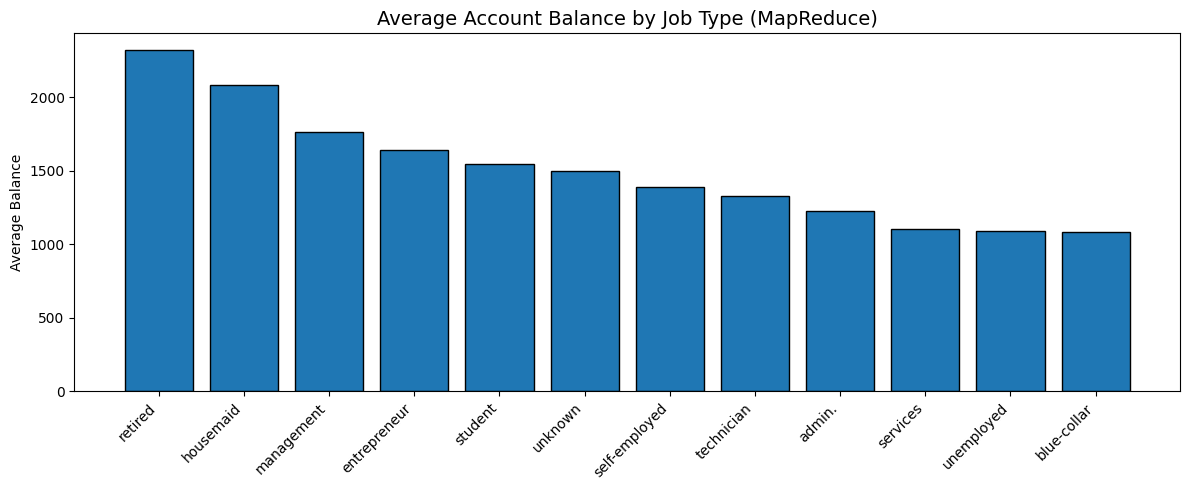

In [ ]:
# Plot MR1 results: Average balance by job category
plt.figure(figsize=(12, 5))

plt.bar(
    mr1_df['Job'],
    mr1_df['Avg_Balance'],
    edgecolor='black'
)

plt.xticks(rotation=45, ha='right')
plt.title('Average Account Balance by Job Type (MapReduce)', fontsize=14)
plt.ylabel('Average Balance')

plt.tight_layout()
plt.savefig('mr1_avg_balance_by_job.png', dpi=150)
plt.show()


## Q2b – MapReduce: Housing Loan Count per Education Category

In [ ]:
# MapReduce Job 2: Housing loan count per education
mapped2 = [((row['education'], row['housing']), 1) for _, row in df.iterrows()]
shuffled2 = defaultdict(int)
for key, val in mapped2:
    shuffled2[key] += val

result_mr2 = pd.DataFrame(
    [(edu, housing, count) for (edu, housing), count in shuffled2.items()],
    columns=['Education', 'Housing_Loan', 'Count']
).sort_values(['Education', 'Housing_Loan'])
print('MapReduce Result: Housing Loan Count per Education Category')
print(result_mr2.to_string(index=False))

MapReduce Result: Housing Loan Count per Education Category
Education Housing_Loan  Count
  primary           no    295
  primary          yes    383
secondary           no    876
secondary          yes   1430
 tertiary           no    687
 tertiary          yes    663
  unknown           no    104
  unknown          yes     83


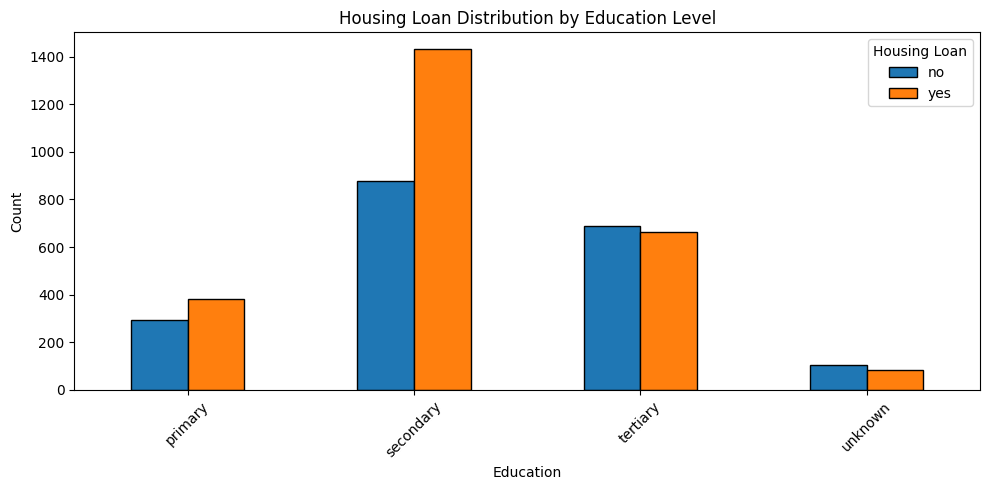

In [ ]:
# Create pivot table and plot results
pivot_table = result_mr2.pivot(
    index='Education',
    columns='Housing_Loan',
    values='Count'
).fillna(0)

pivot_table.plot(
    kind='bar',
    figsize=(10, 5),
    edgecolor='black'
)

plt.title('Housing Loan Distribution by Education Level')
plt.xlabel('Education')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Housing Loan')

plt.tight_layout()
plt.savefig('mr2_housing_by_education.png', dpi=150)
plt.show()

## Q2c – MapReduce: Contacts per Month by Subscription Status

In [ ]:
# MapReduce Job 3
mapped3 = [((row['month'], row['y']), 1) for _, row in df.iterrows()]
shuffled3 = defaultdict(int)
for key, val in mapped3:
    shuffled3[key] += val

month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
result_mr3 = pd.DataFrame(
    [(m, y, c) for (m,y), c in shuffled3.items()],
    columns=['Month','Subscribed','Count']
)
result_mr3['month_idx'] = result_mr3['Month'].map({m:i for i,m in enumerate(month_order)})
result_mr3 = result_mr3.sort_values('month_idx')
print(result_mr3[['Month','Subscribed','Count']].to_string(index=False))

Month Subscribed  Count
  jan         no    132
  jan        yes     16
  feb         no    184
  feb        yes     38
  mar         no     28
  mar        yes     21
  apr        yes     56
  apr         no    237
  may        yes     93
  may         no   1305
  jun        yes     55
  jun         no    476
  jul         no    645
  jul        yes     61
  aug        yes     79
  aug         no    554
  sep         no     35
  sep        yes     17
  oct        yes     37
  oct         no     43
  nov        yes     39
  nov         no    350
  dec        yes      9
  dec         no     11


## Q3a – MapReduce: Avg Contact Duration per Campaign Outcome

In [ ]:
# MapReduce Job 4: Avg duration per poutcome
mapped4 = [(row['poutcome'], row['duration']) for _, row in df.iterrows()]
s4 = defaultdict(lambda: [0,0])
for pout, dur in mapped4:
    s4[pout][0] += dur; s4[pout][1] += 1
result_mr4 = pd.DataFrame(
    [(k, round(v[0]/v[1],2), v[1]) for k,v in s4.items()],
    columns=['poutcome','avg_duration_sec','count']
).sort_values('avg_duration_sec', ascending=False)
print('Average Contact Duration per Campaign Outcome:')
print(result_mr4.to_string(index=False))

Average Contact Duration per Campaign Outcome:
poutcome  avg_duration_sec  count
 success            338.64    129
   other            273.83    197
 unknown            262.10   3705
 failure            254.38    490


## Q3b – MapReduce: Age vs Balance Relationship

Age vs Balance Relationship:
Age_Band  Avg_Balance  Count  Min_Balance  Max_Balance
     10s       393.50      4            0         1169
     20s      1063.66    478        -1202        22171
     30s      1298.15   1808        -1053        27359
     40s      1474.69   1203        -1746        42045
     50s      1547.42    854        -3313        27069
     60s      2619.78    113         -396        71188
     70s      3280.87     47            0        26452
     80s      2071.14     14            0         8304


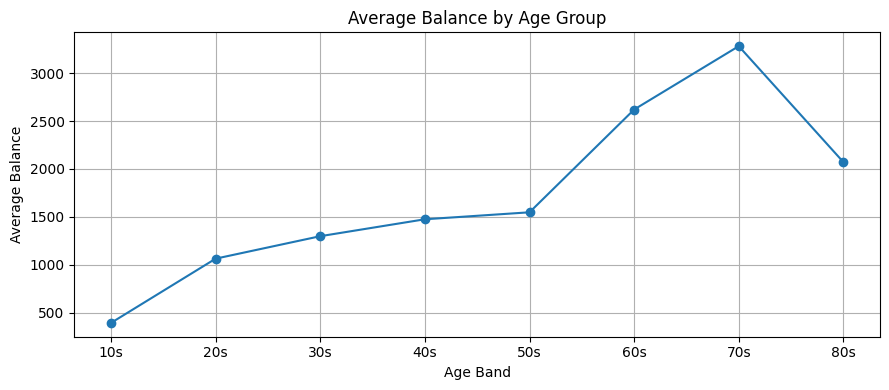

In [ ]:
# MapReduce Job 5: Analyze age groups vs balance

# Map step: group ages into decades and pair with balance
age_balance_pairs = [
    (f"{(row['age'] // 10) * 10}s", row['balance'])
    for _, row in df.iterrows()
]

# Reduce step: aggregate sum, count, min, and max
from collections import defaultdict
aggregates = defaultdict(lambda: [0, 0, float('inf'), float('-inf')])

for age_group, balance in age_balance_pairs:
    aggregates[age_group][0] += balance      # total balance
    aggregates[age_group][1] += 1            # count
    aggregates[age_group][2] = min(aggregates[age_group][2], balance)
    aggregates[age_group][3] = max(aggregates[age_group][3], balance)

# Create final DataFrame
result_mr5 = pd.DataFrame(
    [
        (group, round(vals[0] / vals[1], 2), vals[1], vals[2], vals[3])
        for group, vals in sorted(aggregates.items())
    ],
    columns=['Age_Band', 'Avg_Balance', 'Count', 'Min_Balance', 'Max_Balance']
)

print('Age vs Balance Relationship:')
print(result_mr5.to_string(index=False))

# Visualization
plt.figure(figsize=(9, 4))
plt.plot(
    result_mr5['Age_Band'],
    result_mr5['Avg_Balance'],
    marker='o'
)

plt.title('Average Balance by Age Group')
plt.xlabel('Age Band')
plt.ylabel('Average Balance')

plt.grid(True)
plt.tight_layout()
plt.savefig('mr5_age_vs_balance.png', dpi=150)
plt.show()